<a href="https://colab.research.google.com/github/tejsvinimeshram/Practical6/blob/main/EE524_task6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ============================================================
# SVM for Signal Quality Classification
# Wireless Communication System
# Kaggle IoT Transmission Dataset
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report
)

In [7]:
# 1. Load Dataset
data = pd.read_csv("/content/wireless_signal_quality_dataset.csv")
print("Dataset Preview:")
print(data.head())
print("\nDataset Columns:")
print(data.columns)

Dataset Preview:
   Signal_Strength_dBm  SNR_dB  Interference_dB  Distance_m  Frequency_GHz  \
0                  -41       6                0         257            5.0   
1                  -86      25               20         134            2.4   
2                  -73      27                0         385            2.4   
3                  -57       5                0         255            5.0   
4                  -87      15               24          61            5.0   

   Channel_Bandwidth_MHz  Noise_Floor_dBm  Connected_Devices  \
0                    160             -100                 24   
1                    160              -96                 41   
2                     20              -72                 13   
3                    160              -86                  9   
4                     20              -79                 32   

   Estimated_Throughput_Mbps Quality  
0                         18    Poor  
1                         55    Poor  
2           

In [8]:
# ------------------------------------------------------------
# 2. Create Signal Quality Target
# ------------------------------------------------------------
# Check Delivery_Success classes
print("\nDelivery Success Classes:")
print(data["Quality"].value_counts())
# If only one class exists,
# create Good/Poor quality using RSSI
if data["Quality"].nunique() < 2:
    print("\nOnly one class detected.")
    print("Creating Signal Quality using RSSI...")
    data["Signal_Quality"] = data["Signal_Strength_dBm"].apply(
        lambda x: "Good" if x > -70 else "Poor"
    )
    y = data["Signal_Quality"]
else:
    y = data["Quality"]


Delivery Success Classes:
Quality
Poor         51
Fair         37
Good         10
Excellent     2
Name: count, dtype: int64


In [9]:
# 3. Encode Target
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print("\nTarget Classes:")
print(encoder.classes_)


Target Classes:
['Excellent' 'Fair' 'Good' 'Poor']


In [10]:
# 4. Select Features
X = data[
[
"Distance_m",
"Signal_Strength_dBm",
"Frequency_GHz",
"SNR_dB"
]
]

In [11]:
# 5. Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [12]:
# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

In [13]:
# 7. SVM Model
model = SVC(
kernel="rbf",
C=1,
gamma="scale"
)
# Training
model.fit(
X_train,
y_train
)

SVC(C=1)

In [14]:
# 8. Prediction
y_pred = model.predict(
X_test
)

In [15]:
# 9. Evaluate
print("\nAccuracy:")
print(
round(
accuracy_score(
y_test,
y_pred
)*100,
2
),
)
print("\nClassification Report:")
print(
classification_report(
y_test,
y_pred,
target_names=encoder.classes_
)
)


Accuracy:
70.0

Classification Report:
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00         1
        Fair       0.56      0.71      0.62         7
        Good       0.00      0.00      0.00         2
        Poor       0.82      0.90      0.86        10

    accuracy                           0.70        20
   macro avg       0.34      0.40      0.37        20
weighted avg       0.60      0.70      0.65        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


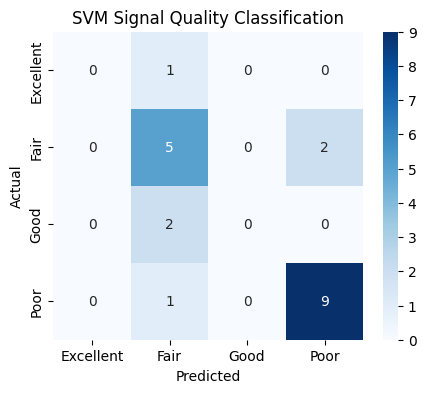

In [16]:
# 10. Confusion Matrix
cm = confusion_matrix(
y_test,
y_pred
)
plt.figure(figsize=(5,4))
sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="Blues",
xticklabels=encoder.classes_,
yticklabels=encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Signal Quality Classification")
plt.show()

In [17]:
# 11. Predict New Signal
new_signal = [[
500, # Distance_m
-65, # Signal_Strength_dBm (using RSSI value)
3, # Frequency_GHz (using Frequency Channel value)
-75 # SNR_dB (using SNR value)
]]
new_signal = scaler.transform(
new_signal
)
prediction = model.predict(
new_signal
)
print("\nNew Signal Quality:")
print(
encoder.inverse_transform(
prediction
)[0]
)


New Signal Quality:
Poor


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
